## Introducción

En estos ejercicios vamos a trabajar con  datasets que representan el conjunto de personajes de Marvel en sus cómics con características de cada uno de ellos.

Las columnas del dataframe significan lo siguiente:

1. `page_id`: Identificador único de la página del personaje dentro de la wikia.
2. `name`: Nombre del personaje.
3. `urlslug`: URL única dentro de la wikia que lleva a la página del personaje.
4. `ID`: Estado de identidad del personaje (Identidad secreta, pública, o sin identidad dual en Marvel).
5. `ALIGN`: Alineación del personaje (Bueno, Malo o Neutral).
6. `EYE`: Color de ojos del personaje.
7. `HAIR`: Color de cabello del personaje.
8. `SEX`: Sexo del personaje (e.g. Masculino, Femenino, etc.).
9. `GSM`: Indica si el personaje pertenece a una minoría de género o sexual (e.g. Homosexual, Bisexual).
10. `ALIVE`: Indica si el personaje está vivo o fallecido.
11. `APPEARANCES`: Número de apariciones del personaje en cómics (al 2 de septiembre de 2014; el número puede estar desactualizado).
12. `FIRST APPEARANCE`: Mes y año de la primera aparición del personaje en un cómic, si está disponible.
13. `YEAR`: Año de la primera aparición del personaje en un cómic, si está disponible.



# Parte 1: Extracción de Datos

Concatena todas las fuentes en un solo Dataset , añade para cada fuente una columna , que indique el origen, a fin de que cuando se concatenen poder tener trazabilidad sobre el origen de donde vino el dato. Para MongoDB usa Mongo Compass


In [433]:
import pandas as pd
import sqlite3
import pyodbc
from pymongo import MongoClient

#LEEMOS EN TODAS LAS FUENTES DE CADA DATASET
df_txt = pd.read_csv('./fuentes_marvel/marvel_characters.txt', sep=';')
df_txt['type'] = 'TXT'
df_xlsx = pd.read_excel('./fuentes_marvel/marvel_characters.xlsx')
df_xlsx['type'] = 'XLSX'
df_json = pd.json_normalize(pd.read_json('./fuentes_marvel/marvel_api_response.json', typ='series')['data'])
df_json['type'] = 'JSON'

#Leer sqlite
conn = sqlite3.connect('./fuentes_marvel/marvel_sqlite.db')
df_sqlite = pd.read_sql('SELECT * FROM marvel_characters', conn)
df_sqlite['type'] = 'SQLITE'
conn.close()

#Leer sql server
conn_sql_server = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=JoelLap;"
    "DATABASE=marvel;"
    "Trusted_Connection=yes"
)
df_sql_server = pd.read_sql('SELECT * FROM dbo.marvel_characters', conn_sql_server)
df_sql_server['type'] = 'SQL SERVER'
conn_sql_server.close()


#Leer MongoDB
with MongoClient('mongodb://localhost:27017/') as client:
    docs = list(client["marvel"]["marvel"].find({}))
df_mongo = pd.DataFrame(docs)
df_mongo['type'] = 'MONGO COMPASS'

C:\Users\Joel\AppData\Local\Temp\ipykernel_16248\3457150990.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql_server = pd.read_sql('SELECT * FROM dbo.marvel_characters', conn_sql_server)


In [434]:
#SI CONCATENAMOS EL DATASET AHORA SERIA UN ERROR YA QUE LOS DATASETS NO COMPARTEN NOMBRE DE COLUMNAS EN COMUN
#ELIMINAMOS COLUMNAS INNECESARIAS
df_mongo = df_mongo.drop('_id', axis='columns')

#DEFINIMOS EL MISMO NOMBRE DE COLUMNAS PARA TODOS LOS DATAFRAMES PARA QUE HAYA CONSISTENCIA EN LOS DATOS Y NO SE CREEN COLUMNAS APARTE
cols_const = ['page_id','name','urlslug','ID','ALIGN','EYE','HAIR','SEX','GSM','ALIVE','APPEARANCES','FIRST_APPEARANCE','YEAR','TYPE']
df_txt.columns = cols_const
df_xlsx.columns = cols_const
df_json.columns = cols_const
df_sqlite.columns = cols_const
df_sql_server.columns = cols_const
df_mongo.columns = cols_const

In [435]:
#CONCATENAMOS LOS DATASETS Y VERIFICAMOS LAS COLUMNAS
df_marvel = pd.concat([df_txt, df_xlsx, df_json, df_sqlite, df_sql_server, df_mongo], ignore_index=True)
df_marvel.columns

Index(['page_id', 'name', 'urlslug', 'ID', 'ALIGN', 'EYE', 'HAIR', 'SEX',
       'GSM', 'ALIVE', 'APPEARANCES', 'FIRST_APPEARANCE', 'YEAR', 'TYPE'],
      dtype='object')

In [436]:
#VERIFICAMOS LA LA CONCATENACION
df_marvel.head()

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST_APPEARANCE,YEAR,TYPE
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,NaN,1962.0,TXT
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,NaN,1941.0,TXT
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,NaN,1974.0,TXT
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2961.0,NaN,1963.0,TXT
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,2258.0,NaN,1950.0,TXT


# Parte 2: Análisis Exploratorio y Limpieza de Datos

En esta sección el estudiante debe realizar el análisis exploratorio de datos (EDA), se detectarán outliers, se limpiará el dataset y se responderán preguntas sobre los datos.


## 2.1 EDA Inicial

Se realiza un análisis exploratorio inicial del dataset para comprender su estructura, tipos de datos, cantidad de valores nulos y estadísticas descriptivas básicas.


In [437]:
#FORMA Y TIPOS DE DATOS
print("Forma del dataframe: ", df_marvel.shape)
print("Columnas con sus tipos de datos:")
print(df_marvel.dtypes)

Forma del dataframe:  (98256, 14)
Columnas con sus tipos de datos:
page_id              int64
name                object
urlslug             object
ID                  object
ALIGN               object
EYE                 object
HAIR                object
SEX                 object
GSM                 object
ALIVE               object
APPEARANCES         object
FIRST_APPEARANCE    object
YEAR                object
TYPE                object
dtype: object


In [438]:
#VALORES NULOS POR COLUMNAS
print("Cantidad de valores nulos: ")
print(df_marvel.isnull().sum())

Cantidad de valores nulos: 
page_id                 0
name                    0
urlslug                 0
ID                  11310
ALIGN                8436
EYE                 29301
HAIR                12792
SEX                  2562
GSM                 48858
ALIVE                   9
APPEARANCES          4384
FIRST_APPEARANCE    18006
YEAR                 3260
TYPE                    0
dtype: int64


In [439]:
#ESTADISTICAS DESCRIPTIVAS BASICAS
display(df_marvel.info())
print("-"*50)
display(df_marvel.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98256 entries, 0 to 98255
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   page_id           98256 non-null  int64 
 1   name              98256 non-null  object
 2   urlslug           98256 non-null  object
 3   ID                86946 non-null  object
 4   ALIGN             89820 non-null  object
 5   EYE               68955 non-null  object
 6   HAIR              85464 non-null  object
 7   SEX               95694 non-null  object
 8   GSM               49398 non-null  object
 9   ALIVE             98247 non-null  object
 10  APPEARANCES       93872 non-null  object
 11  FIRST_APPEARANCE  80250 non-null  object
 12  YEAR              94996 non-null  object
 13  TYPE              98256 non-null  object
dtypes: int64(1), object(13)
memory usage: 10.5+ MB


None

--------------------------------------------------


,page_id
count,98256.000000
mean,300232.082377
std,253453.954271
min,1025.000000
25%,28309.500000
50%,282578.000000
75%,509077.000000
max,755278.000000


### Gráfico 1: Distribución por Alineación (ALIGN)

Visualiza cuántos personajes hay de cada tipo de alineación (Bueno, Malo, Neutral, etc.).


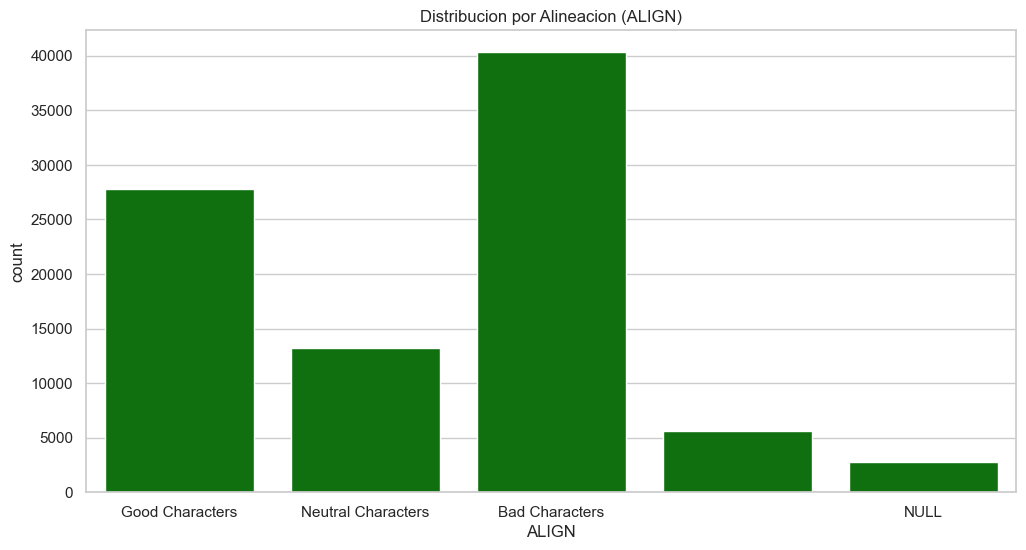

In [440]:
import seaborn as sns
import matplotlib.pyplot as plt

#CONFIGURAMOS EL TAMAÑO DEL GRAFICO
plt.figure(figsize=(12, 6))

# Grafica el conteo de personajes por alineación (countplot para contar la frecuencia de un texto en una columna)
sns.countplot(data=df_marvel, x='ALIGN', color='green')

plt.title('Distribucion por Alineacion (ALIGN)')
plt.show()

`Podemos observar mediante la grafica que los personajes con una alineacion "Mala" son los mas frecuentes. En segundo lugar tenemos a los personajes con una alineacion "Buena", en tercer lugar estan los personajes "Neutral" y finalmente estan los valores nulos (NULL). `

`Adicional, existe una barra aparentemente sin un indice explicito, esto se puede deber a que existen valores vacios (espacios en blanco o NaN) y por eso, la grafica no los cuenta como NULL.`

## 2.2 Cálculo de Outliers




In [441]:
#CONVERTIR COLUMNAS DE TIPO OBJECT A FLOAT
df_marvel['APPEARANCES'] = pd.to_numeric(df_marvel['APPEARANCES'], errors='coerce')
df_marvel['YEAR'] = pd.to_numeric(df_marvel['YEAR'], errors='coerce')

#CONVERTIMOS A INT CADA COLUMNA CORRESPONDIENTE QUE SEA DE TIPO INT
df_marvel['APPEARANCES'] = df_marvel['APPEARANCES'].astype('Int64')
df_marvel['YEAR'] = df_marvel['YEAR'].astype('Int64')

In [442]:
#Seleccionar solo las columnas numericas del dataframe 'df_marvel'
columnas_numericas = df_marvel.select_dtypes(include="number").columns

#Lista donde se va a guardar el resumen de outliers por cada columna
resumen_outliers = []

#Recorrer cada columna numerica para calcular sus limites de outliers
for col in columnas_numericas:
    #Q1: percentil bajo el 25%
    Q1 = df_marvel[col].quantile(0.25)

    #Q3: percentil bajo el 75%
    Q3 = df_marvel[col].quantile(0.75)

    #IQR: Rango Intercuanilico
    IQR = Q3 - Q1

    #Limites para detectar outlieres segun la regla: Q1-1.5xIQR / Q3+1.5xIQR
    limite_inferior = max(0, Q1 - 1.5 * IQR)
    limite_superior = Q3 + 1.5 * IQR

    #Filtrar las filas con valores fuera de los limites (es decir, otuliers)
    outliers = df_marvel[(df_marvel[col] < limite_inferior) | (df_marvel[col] > limite_superior)]

    #Guardar el resumen de estadisticas en la lista resumen_outliers
    resumen_outliers.append({
        "columna" : col,
        "Q1" : Q1,
        "Q3" : Q3,
        "IQR" : IQR, 
        "limite_inferior" : limite_inferior,
        "limite_superior" : limite_superior,
        "cantidad_outliers" : outliers.shape[0]
    })

#Convertir la lista del diccionario en dataframe y ordenar por cantidad de outliers (mayor a menor)
tabla_resumen_outliers = pd.DataFrame(resumen_outliers).sort_values("cantidad_outliers", ascending = False)
tabla_resumen_outliers

,columna,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers
1,APPEARANCES,1.0,8.0,7.0,0.0,18.50,11628
0,page_id,28309.5,509077.0,480767.5,0.0,1230228.25,0
2,YEAR,1974.0,2000.0,26.0,1935.0,2039.00,0


### Gráfico 3: Diagrama BoxPlot 

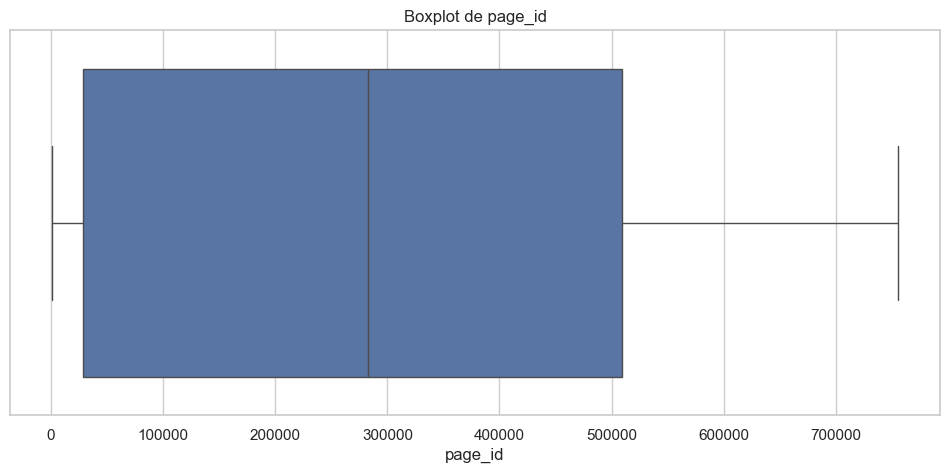

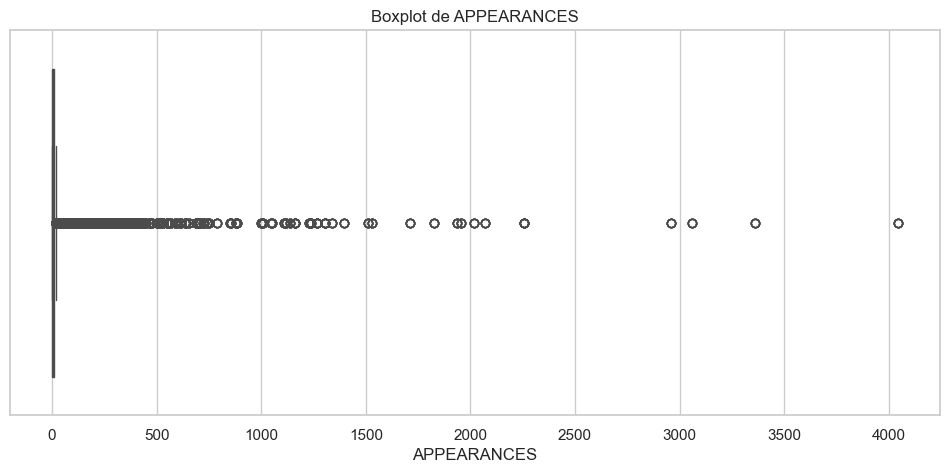

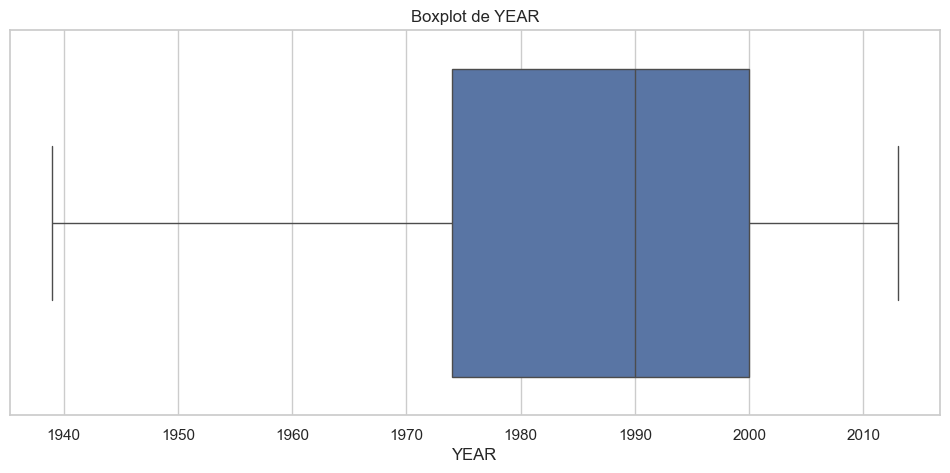

In [443]:
#Seleccionar todas las columnas que sean numericas
num_cols = df_marvel.select_dtypes(include=['float64', 'int64']).columns  #Tambien se puede poner directamente 'number'

for col in num_cols:
    plt.figure(figsize=(12, 5)) #Se define el tamaño de la figura
    sns.boxplot(x=df_marvel[col]) #Dibujo la parte horizontal del BoxPlot
    plt.title(f'Boxplot de {col}')  #Titulo con el nombre de la columna

### Gráfico 4: Diagrama de densidad de núcleo (KDE)

C:\Users\Joel\AppData\Local\Temp\ipykernel_16248\865235729.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_marvel, x='APPEARANCES', shade=True, color='purple')


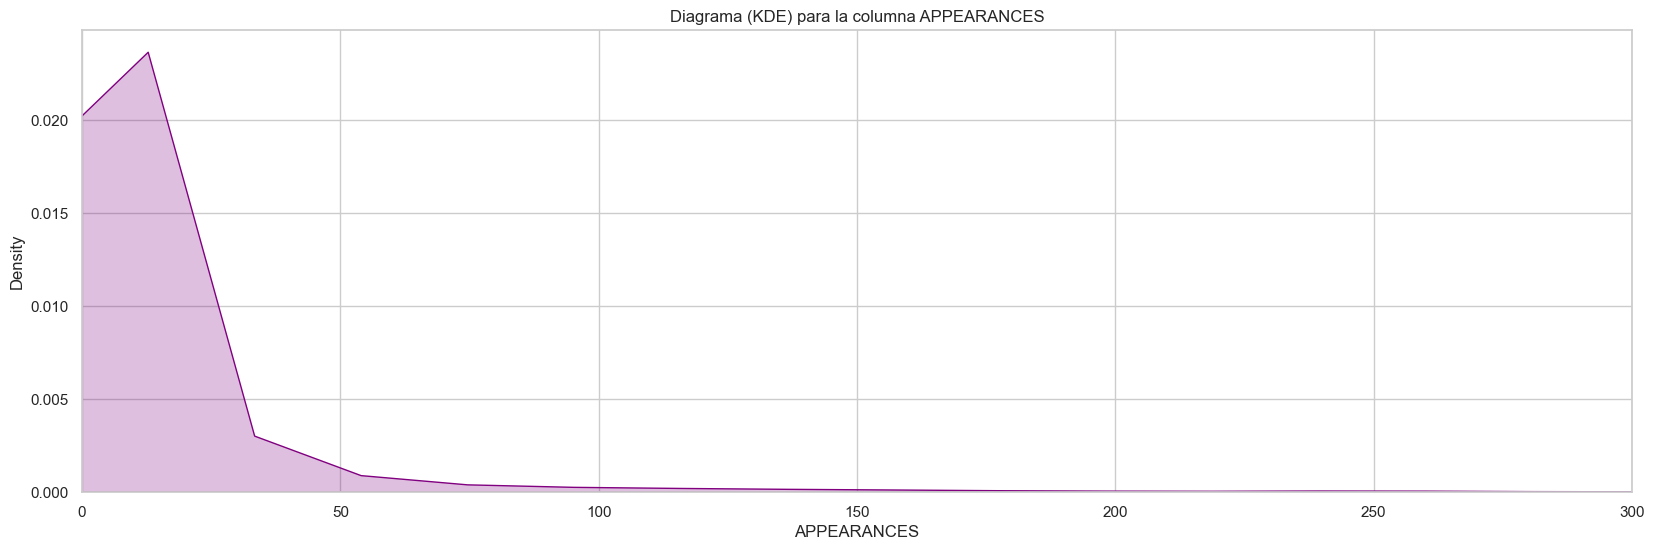

In [444]:
#TRABAJAMOS SOLO CON LA COLUMNA "APPAREANCES" YA QUE ES LA UNICA COLUMNA NUMERICA CUANTITATIVA, LAS DEMAS, NO NOS SIRVE PARA REALIZAR ESTE GRAFICO
sns.set_theme(style='whitegrid')
plt.figure(figsize=(20, 6))
sns.kdeplot(data=df_marvel, x='APPEARANCES', shade=True, color='purple')
plt.xlim(0, 300)

plt.title("Diagrama (KDE) para la columna APPEARANCES")
plt.show()

## 2.3 Limpieza de Datos

Se debe aplicar los siguientes pasos de limpieza:

- **Eliminar duplicados** exactos del dataset.
- **Imputar valores nulos** en columnas categóricas con `'Desconocido'`.
- **Imputar valores nulos** en columnas numéricas con la **mediana** de la columna.


In [445]:
#Eliminar duplicados exactos del dataset
df_marvel.drop_duplicates(inplace=True)

#Imputa valores nulos en columnas categoricas
cols_categoricas = df_marvel.select_dtypes(include=['object']).columns
df_marvel[cols_categoricas] = df_marvel[cols_categoricas].fillna('Desconocido')

#Imputar valores nulos en columnas numericas con la mediana de la columna
cols_numericas = df_marvel.select_dtypes(include=['number']).columns
for col in cols_numericas:
    mediana = df_marvel[col].mean()
    df_marvel[col] = df_marvel[col].fillna(mediana.astype(int))

#Verificacion de que no existan valores nulos
df_marvel.isnull().sum()

page_id             0
name                0
urlslug             0
ID                  0
ALIGN               0
EYE                 0
HAIR                0
SEX                 0
GSM                 0
ALIVE               0
APPEARANCES         0
FIRST_APPEARANCE    0
YEAR                0
TYPE                0
dtype: int64

Consulta y responde, para imputar valores nulos en columnas numericas, cuando es recomendable hacerlo con la media, la mediana, la moda o talvez existen alguna otra técnica?. Responde para cada caso cuando es recomendable

`Es recomendable imputar con la media cuando los datos tienen una distribucion normal y no son outliers.`


`Es recomendable imputar con la mediana siempre y cuando hayan demasiados outliers.`


`Es recomendable imputar con la moda en columnas categoricas o solo cuando un valor se repite dominantemente en una columna numerica.`


`Tambien es recomendable imputar con algoritmos (como K-Nearest Neighbors) que mira las caracteristicas de las otras columnas para tratar de "adivinar" el numero mas logico.`

## 2.4 EDA PROFUNDO

Ejercicio 1. Comparación de personajes por década de creación  
Crea una columna de décadas a partir de YEAR.  
Cuenta cuántos personajes fueron creados en cada década.  
Identifica las décadas con mayor número de personajes.  
Realiza una breve interpretación de la evolución de creación de personajes a lo largo del tiempo.  



In [446]:
#DIVIDIMOS PARA OBTENER LA PARTE ENTERA (POR EJEMPLO: 1994 // 10 = 199) Y LUEGO MULTIPLICAMOS POR 10 PARA OBTENER LA DECADA
df_marvel['DECADA'] = (df_marvel['YEAR'] // 10) * 10

#TOTAL DE PERSONAJES CREADOS POR DECADA
df_marvel.groupby('DECADA')['name'].nunique()

#DECADAS CON MAYOR NUMERO DE PERSONAJES
df_marvel.groupby('DECADA')['name'].nunique().sort_values(ascending=False)

DECADA
1990    3657
1980    3240
2000    3086
1970    2234
1940    1441
1960    1306
2010    1041
1950     302
1930      69
Name: name, dtype: int64

`Podemos observar que las 3 decadas con mayor numero de personajes creados fue entre la decada de 1980 y 2000.`

`Ademas, se puede concluir que la creacion de personajes ha ido aumentando de forma ascendente desde que se tiene registro en 1930 hasta el 2010.`

`A partir del 2010 se puede notar una considerable reduccion en la creacion de personajes en dicha epoca.`

## 2.5 Preguntas

Responde las siguientes preguntas utilizando el dataset limpio:

1. ¿Cuántos personajes están vivos y cuántos han fallecido?
2. ¿Cuál es el color de cabello más común entre los personajes buenos?
3. ¿Qué porcentaje de personajes tiene identidad secreta?
4. ¿Cuál fue el año en que se crearon más personajes?


In [447]:
df_marvel[(df_marvel['ALIVE'] == 'Living Characters') | (df_marvel['ALIVE'] == 'Deceased Characters')].groupby('ALIVE')['ALIVE'].count()


ALIVE
Deceased Characters    22590
Living Characters      75648
Name: ALIVE, dtype: int64

1. ¿Cuántos personajes están vivos y cuántos han fallecido?

`Hay 75648 personajes vivos.`  
`Hay 22590 personajes muertos`

In [448]:
df_marvel[df_marvel['ALIGN'] == 'Good Characters'].groupby('ALIGN')['HAIR'].value_counts().sort_values(ascending=False).head(3)


ALIGN            HAIR      
Good Characters  Black Hair    6876
                 Brown Hair    4656
                 Blond Hair    3768
Name: count, dtype: int64

2. ¿Cuál es el color de cabello más común entre los personajes buenos?

`Entre los personajes buenos, el color de cabello mas comun es: Negro con 6876 personajes`

In [449]:
(df_marvel['ID'].value_counts(normalize=True) * 100).round(2)


ID
Secret Identity                  38.32
Public Identity                  27.65
Desconocido                      11.51
No Dual Identity                 10.92
                                  7.67
NULL                              3.84
Known to Authorities Identity     0.09
Name: proportion, dtype: float64

3. ¿Qué porcentaje de personajes tiene identidad secreta?

`Hay un 38.32% de personajes que tienen identidad secreta.`

In [450]:
df_marvel.groupby('YEAR')['name'].nunique().sort_values(ascending=False).head()


YEAR
1984    1039
1993     554
1994     485
1992     455
2006     381
Name: name, dtype: int64

4. ¿Cuál fue el año en que se crearon más personajes?

`Fue en el año de 1984 donde se crearon 1039 personajes.`

# Parte 3: Visualización de Datos(COMUNICACION DE INFORMACIÓN)


### EJERCICIO 1. Gráfico de tendencia: Evolución de la cantidad de personajes creados por año

- Analiza la cantidad de personajes creados cada año (YEAR).
- Crea un gráfico de línea que muestre la evolución del número de personajes creados a lo largo del tiempo.
- Realiza una interpretación del gráfico


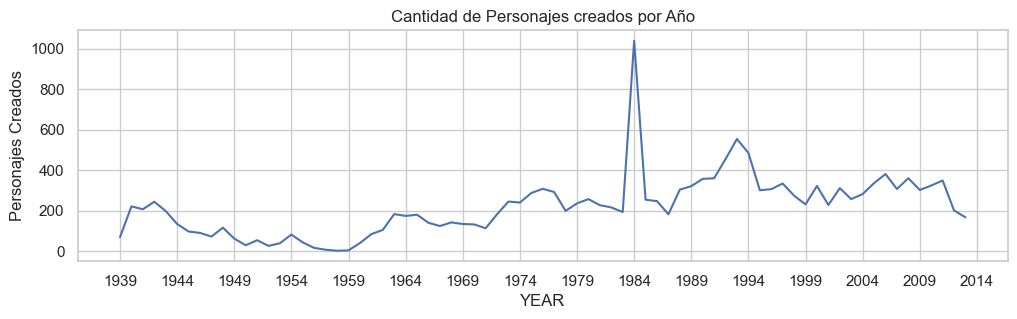

In [451]:
#Agrupo los personajes por YEAR y calculo la cantidad de personajes unicos de cada año
# as_index=False para mantener 'YEAR' como columna y no como indice
#.nunique() PARA CONTAR LOS PERSONAJES UNA UNICA VEZ Y QUE NO SE SUMEN LOS PERSONAJES DUPLICADOS SOLO LOS UNICOS 
personajes_creados_por_anio = df_marvel.groupby('YEAR', as_index=False)['name'].nunique()

#DEFINIMOS EL DISEÑO DEL GRAFICO
plt.figure(figsize=(12, 3))
sns.lineplot(data=personajes_creados_por_anio, x='YEAR', y='name')

#DEFINO EL RANGO QUE TENDRA EL EJE X (YEAR)
plt.xticks(
    range(personajes_creados_por_anio['YEAR'].min(), personajes_creados_por_anio['YEAR'].max() + 5, 5)
)

plt.title('Cantidad de Personajes creados por Año')
plt.xlabel('YEAR')
plt.ylabel('Personajes Creados')
plt.show()

`En el grafico podemos observar que en 1984 fue el año donde se creo mas personajes que en el resto de años registrados.`  

`Ademas, podemos observar que inmediatamente despues, la cantidad de personajes disminuyo drasticamente hasta 1987-1988 donde comenzo a tener una tendencia mas equilibrada hasta el ultimo año registrado.`

### EJERCICIO 2. Mapa de calor: Relación entre alineación y estado vivo/fallecido

- Analiza la relación entre la alineación del personaje (ALIGN) y su estado (ALIVE).
- Muestra un mapa de calor que cuente cuántos personajes de cada tipo (Bueno, Malo, Neutral) están vivos o fallecidos.
- Saca una conclusión del gráfico.


<Axes: xlabel='ALIVE', ylabel='ALIGN'>

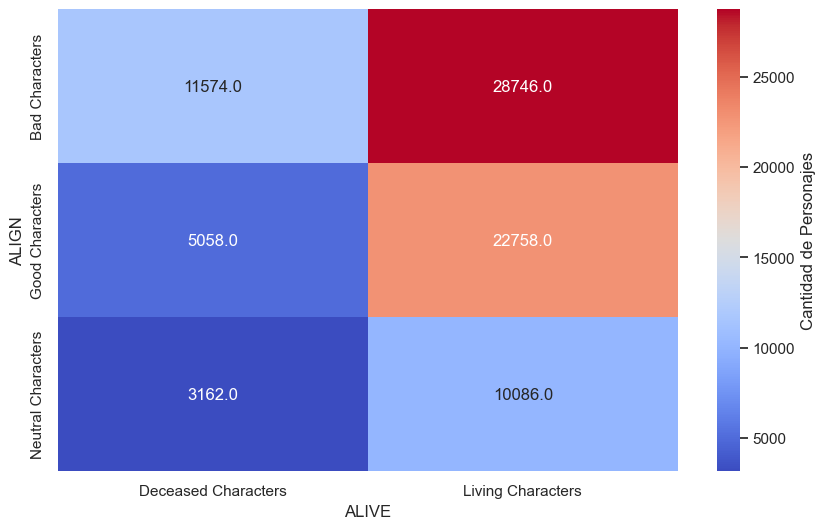

In [452]:
#FILTRO SOLO LAS COLUMNAS CON LOS VALORES NECESARIOS, LOS ESPACIOS EN BLANCO O MARCADOS COMO NULL LOS IGNORO
df_align_alive = df_marvel[((df_marvel['ALIGN'] == 'Good Characters') | 
                           (df_marvel['ALIGN'] == 'Bad Characters') | 
                           (df_marvel['ALIGN'] == 'Neutral Characters')) &
                           ((df_marvel['ALIVE'] == 'Living Characters') | (df_marvel['ALIVE'] == 'Deceased Characters'))
                           ]

#AGRUPO LA COLUMNA ALIGN CON ALIVE
align_alive = df_align_alive.groupby('ALIGN')['ALIVE'].value_counts().unstack()

#GENERO EL MAPA DE CALOR
plt.figure(figsize=(10,6))
sns.heatmap(align_alive, annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label':'Cantidad de Personajes'})

`El grafico nos muestra que hay 28746 personajes MALOS que estan VIVOS. Podemos concluir que domina la supervivencia, sin embargo existe una diferencia notoria en la mortalidad: los personajes malos tiene mas del doble de muertos que los personajes buenos y, los personajes neutrales muertos es una tercera parte de los personajes neutros vivos.`

### EJERCICIO 3. Histograma: Distribución del número de creación de personajes por décadas

- Analiza cómo se distribuyen la creación de los personas por décadas (Year).
- Crea un histograma cuantos personajes se crearon para cada década.


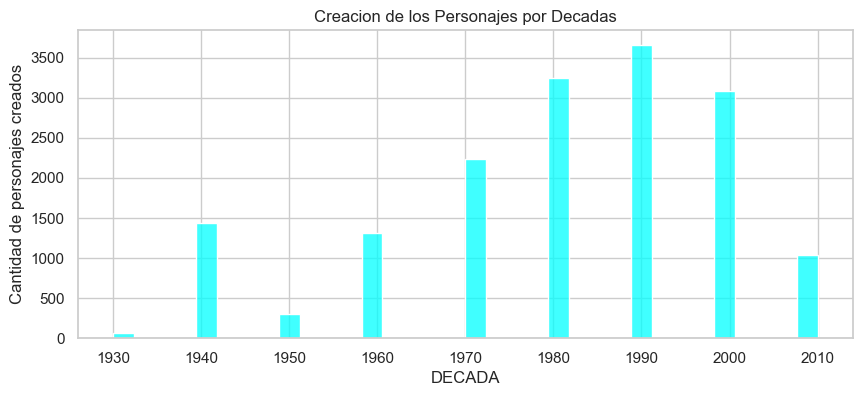

In [453]:
#ELIMINAMOS LOS DUPLICADOS DE LA COLUMNA "NAME" PARA EVITAR LOS PERSONAJES REPETIDOS
#COMO LOS PERSONAJES YA HAN SIDO CREADOS, NO PUEDEN PERTENECER A 2 EPOCAS DIFERENTES
df_marvel_sin_duplicados = df_marvel.drop_duplicates(subset=['name'])

plt.figure(figsize=(10, 4))

#.histplot para graficar un histograma y le pasamos el dataframe sin duplicados, la columna que queremos graficar y el color de las barras.
sns.histplot(df_marvel_sin_duplicados, x='DECADA', color='aqua')
plt.title("Creacion de los Personajes por Decadas")
plt.ylabel("Cantidad de personajes creados")
plt.show()

`Viendo el grafico podemos concluir que: en la decada donde mas se crearon personajes fue en 1990 y en la decada que menos personajes creados tuvo fue en la de 1930 y 1950.`

### EJERCICIO 4. Crea 4 diagramas adicionales, diferentes a los ya usados en este deber e interpreta los resultados, cada uno deberia mostrar información relevante que considera el estudiante mostrar.

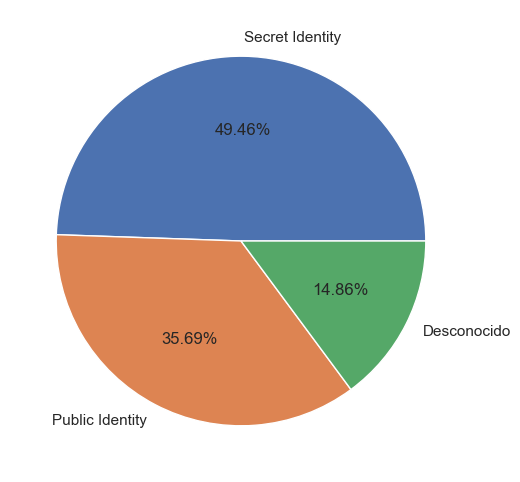

In [454]:
#GRAFICO DE PASTEL

#FILTRO SOLO LAS CATEGORIAS QUE SON RELEVANTES; VALORES NULOS O ESPACIOS EN BLANCO LAS EVITO
df_marvel_id_limpio = df_marvel[(df_marvel['ID'] == 'Public Identity') | (df_marvel['ID'] == 'Secret Identity') | (df_marvel['ID'] == 'Desconocido')]

# autopct='%1.1f%%' PARA QUE SEA EN FORMATO DE PORCENTAJES
plt.figure(figsize=(6, 6))
df_marvel_id_limpio['ID'].value_counts().plot.pie(autopct='%1.2f%%')

#ELIMINO UNA ETIQUETA INNECESARIA
plt.ylabel('')
plt.show()

`El grafico nos muestra el porcentaje de identidad de todos los personajes registrados en el dataset.`

`Se puede observar que IDENTIDAD SECRETA lidera con un 49.46% seguido de IDENTIDAD PUBLICA con un 35.69% y por ultimo DESCONOCIDO con un 14.89%.`

`Podemos concluir que hay MAS personajes con IDENTIDAD SECRETA que con identidad publica o desconocida.`

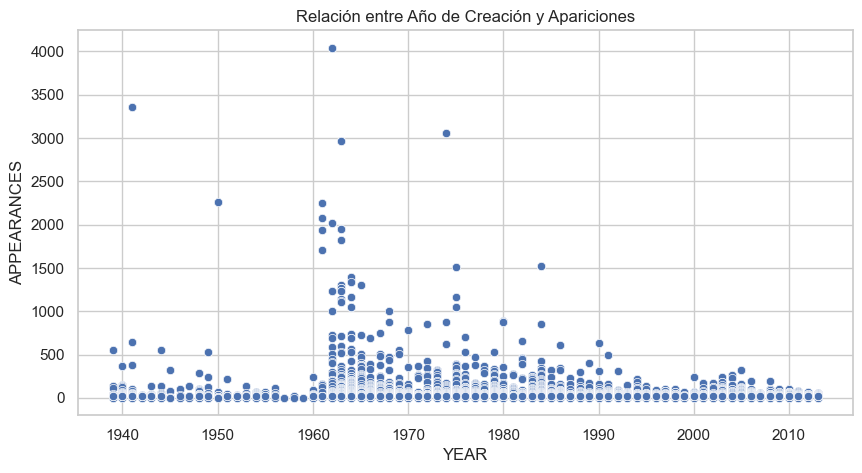

In [455]:
#GRAFICO DE DISPERSION 

#USAMOS .scatterplot PARA CREAR EL GRAFICO DE DISPERSION
#SOLO HACE FALTA IDENTIFICAR QUE COLUMNA ES X Y QUE COLUMNA ES Y
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_marvel, x='YEAR', y='APPEARANCES')

plt.title("Relación entre Año de Creación y Apariciones")
plt.show()

`El grafico nos muestra la relacion que existe entre el año de creacion del personaje y el numero de apariciones que tuvieron esos personajes.`

`Podemos observar algo interesante, los personajes que mas apariciones tienen son los personajes que fueron creados en las primeras decadas (entre 1940 a 1970). Por otro lado, los personajes que fueron creado a partir de la decada de los 2000 tienen muy pocas apariciones.`

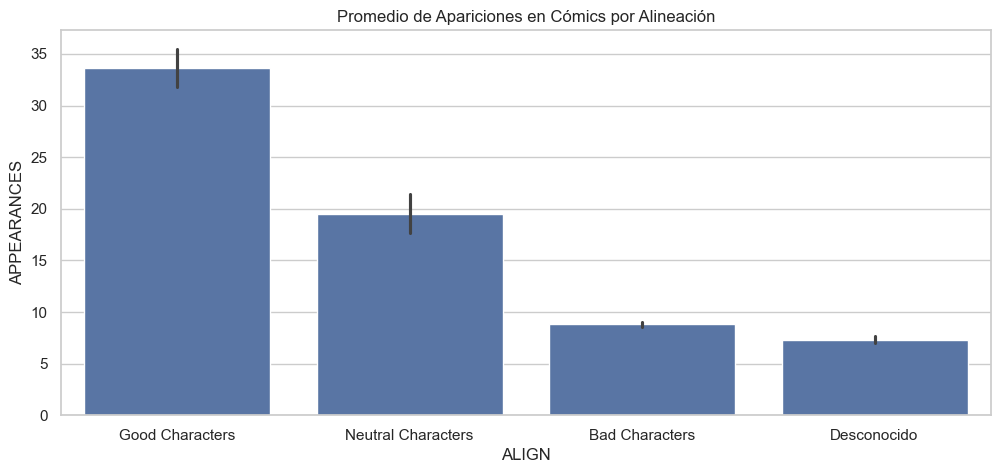

In [456]:
#GRAFICO DE BARRAS CON PROMEDIO AUTOMATICO 

#FILTRO CATEGORIAS RELEVANTES, EL RESTO (COMO NULOS O ESPACIOS EN BLANCO) LOS EVITO
df_align_limpio = df_marvel[(df_marvel['ALIGN'] == 'Good Characters') |
                             (df_marvel['ALIGN'] == 'Neutral Characters') |
                               (df_marvel['ALIGN'] == 'Bad Characters') |
                               (df_marvel['ALIGN'] == 'Desconocido')]

# Por defecto, barplot calcula el PROMEDIO de la variable Y
plt.figure(figsize=(12, 5))
sns.barplot(data=df_align_limpio, x='ALIGN', y='APPEARANCES')

plt.title("Promedio de Apariciones en Cómics por Alineación")
plt.show()

`Este grafico nos indica el promedio de apariciones. `

`Se puede observar que los personajes BUENOS tienen mas del triple participaciones (o apariciones) que los personajes malos y desconocidos. `

C:\Users\Joel\AppData\Local\Temp\ipykernel_16248\1779258440.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_align_limpio, x='ALIVE', y='YEAR', palette='pastel')


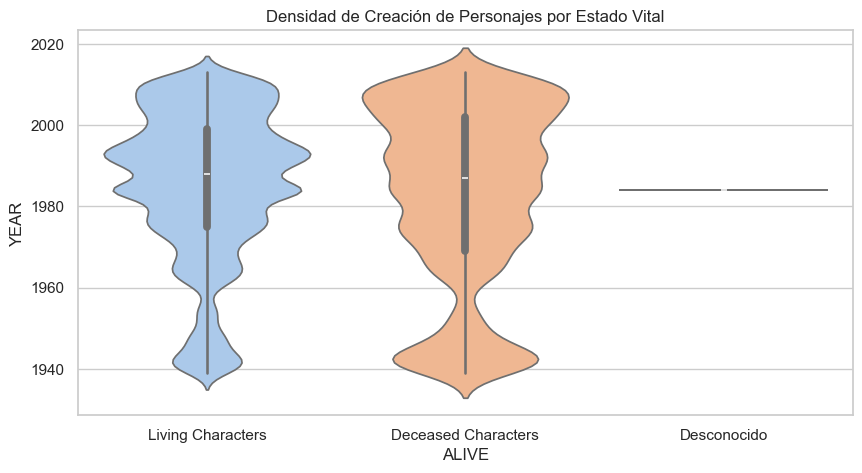

In [457]:
#FILTRAR LAS CATEGORIAS RELEVANTES, EL RESTO LAS EVITO
df_alive_limpio = df_marvel[(df_marvel['ALIVE'] == 'Living Characters') |
                             (df_marvel['ALIVE'] == 'Deceased Characters') |
                               (df_marvel['ALIVE'] == 'Desconocido')]

# Funciona con la misma sintaxis exacta que un boxplot
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_align_limpio, x='ALIVE', y='YEAR', palette='pastel')

plt.title("Densidad de Creación de Personajes por Estado Vital")
plt.show()

`Este grafico combina un boxplot (diagrama de caja) con la forma de un histograma suavizado.`

`El diagrama de violin muestra en que decadas se concentra la creacion de los personajes. El grosor de la figura indica mayor cantidad de creacion de personajes.`

`Se puede observar del grafico que personajes tanto vivos como muertos provienen de los años 1980 hasta 2020 (ya que el violin tiene mas grosor en estos años). El puntito blanco referencia a la mediana y al estar cerca de 1990 significa que todos los personajes provienen de 1990 en adelante.`

`Ademas, se observa que en los años de 1940 a 1960 el violion tiene un grosor extremadamente pequeño, esto nos indica que casi no hay datos ahi.` 
